In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('CRH','NVDA'), 
         ('CRH','AAPL'), 
         ('CRH','MSFT'), 
         ('TDG','NVDA'), 
         ('TDG', 'AAPL'),
         ('TDG', 'MSFT'), 
         ('NEM','NVDA'), 
         ('NEM', 'AAPL'), 
         ('NEM','MSFT')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, 

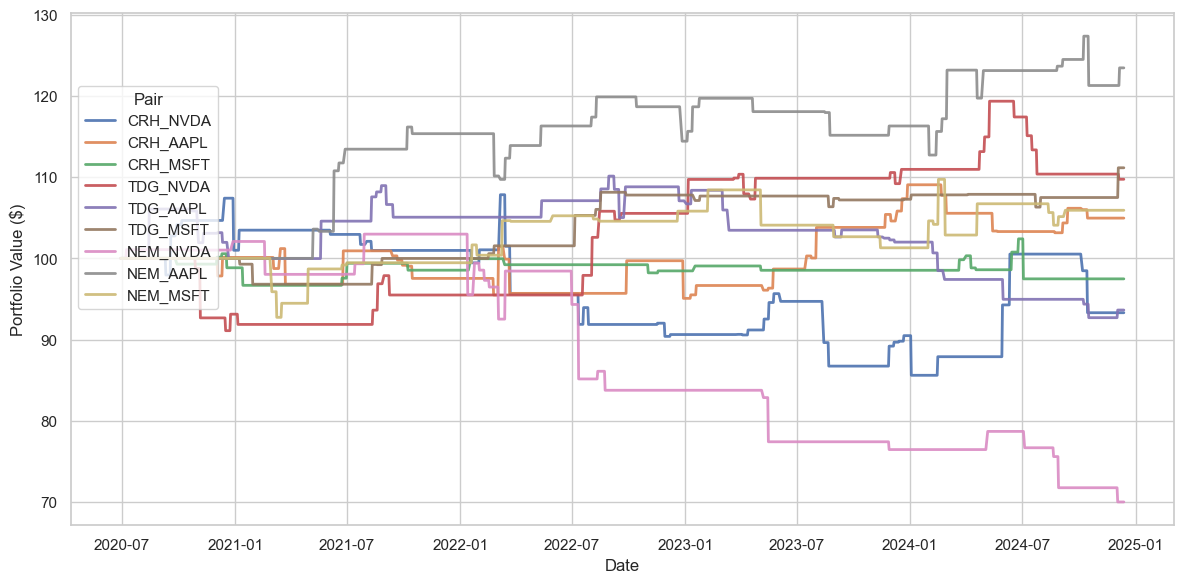

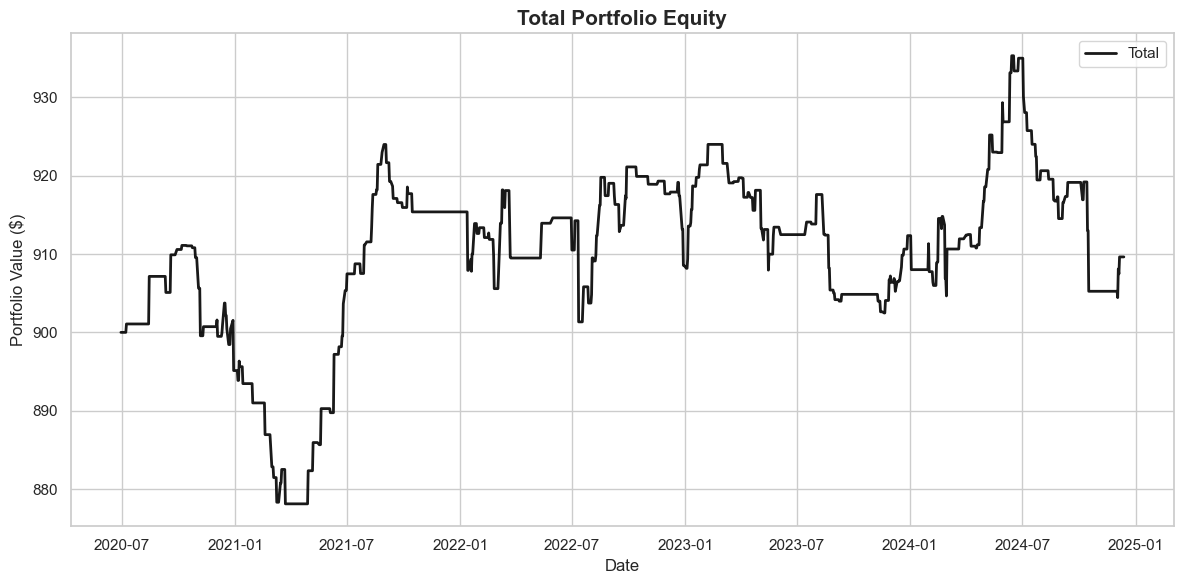

Summary
CRH_NVDA: Final Value = $93.30, Total Return = -6.70%, Trades = 41
CRH_AAPL: Final Value = $104.95, Total Return = 4.95%, Trades = 39
CRH_MSFT: Final Value = $97.47, Total Return = -2.53%, Trades = 22
TDG_NVDA: Final Value = $109.74, Total Return = 9.74%, Trades = 31
TDG_AAPL: Final Value = $93.64, Total Return = -6.36%, Trades = 37
TDG_MSFT: Final Value = $111.15, Total Return = 11.15%, Trades = 23
NEM_NVDA: Final Value = $70.01, Total Return = -29.99%, Trades = 26
NEM_AAPL: Final Value = $123.45, Total Return = 23.45%, Trades = 34
NEM_MSFT: Final Value = $105.92, Total Return = 5.92%, Trades = 27

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $909.63
Total Return:            1.07%

Sharpe Ratios
CRH_NVDA: Sharpe Ratio = -0.10
CRH_AAPL: Sharpe Ratio = 0.19
CRH_MSFT: Sharpe Ratio = -0.15
TDG_NVDA: Sharpe Ratio = 0.36
TDG_AAPL: Sharpe Ratio = -0.21
TDG_MSFT: Sharpe Ratio = 0.72
NEM_NVDA: Sharpe Ratio = -0.82
NEM_AAPL: Sharpe Ratio = 0.69
N

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)